# Harsh Driving Event Detection (XGBoost)

This notebook trains an XGBoost model for harsh driving event detection.
It uses a 70/30 group split by source file and evaluates test confusion matrix.

In [3]:
# If needed, uncomment and run once.
%pip install -q xgboost pandas numpy scikit-learn imbalanced-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path.cwd().resolve().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
DATASET_DIR = ROOT / 'dataset'
SRC_DIR = ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from harsh_event_model import load_row_labeled_data

sns.set_style('whitegrid')
print(f'ROOT={ROOT}')
print(f'DATASET_DIR exists: {DATASET_DIR.exists()}')

ROOT=C:\Users\vigne\Downloads\carla-project-main
DATASET_DIR exists: True


In [6]:
# Load row-level data and add derived features.
row_labeled_df = load_row_labeled_data(DATASET_DIR)
imu_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']

clean_df = row_labeled_df.copy()
for col in imu_cols:
    clean_df[col] = (
        clean_df.groupby('source_file')[col]
        .transform(lambda s: s.rolling(window=3, min_periods=1, center=True).median())
    )

clean_df['acc_mag'] = np.sqrt(clean_df['acc_x']**2 + clean_df['acc_y']**2 + clean_df['acc_z']**2)
clean_df['gyro_mag'] = np.sqrt(clean_df['gyro_x']**2 + clean_df['gyro_y']**2 + clean_df['gyro_z']**2)
clean_df['mag_mag'] = np.sqrt(clean_df['mag_x']**2 + clean_df['mag_y']**2 + clean_df['mag_z']**2)

for axis in ['acc_x', 'acc_y', 'acc_z']:
    clean_df[f'{axis}_jerk'] = clean_df.groupby('source_file')[axis].diff().fillna(0.0)

clean_df['lat_long_ratio'] = clean_df['acc_y'].abs() / (clean_df['acc_x'].abs() + 1e-6)

clean_df.head()

,sr_no,timestamp,road_type,harsh_event,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,...,event_class,event_label,source_file,acc_mag,gyro_mag,mag_mag,acc_x_jerk,acc_y_jerk,acc_z_jerk,lat_long_ratio
0,1,28-2-2023_16:3:23:442849,paved,uniform-accel,-0.198483,-1.942927,-1.056091,-0.081648,-0.001504,-0.004192,...,0,safe,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,2.220290,0.081769,163.724797,0.000000,0.000000,0.000000,9.788829
1,2,28-2-2023_16:3:23:832886,paved,uniform-accel,-0.255964,-1.267521,-0.610611,-0.076188,0.002490,-0.003659,...,0,safe,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,1.430026,0.076317,163.724797,-0.057481,0.675406,0.445480,4.951923
2,3,28-2-2023_16:3:23:848095,paved,uniform-accel,-0.255964,-1.267521,-0.610611,-0.076188,0.002490,-0.001795,...,0,safe,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,1.430026,0.076250,163.587358,0.000000,0.000000,0.000000,4.951923
3,4,28-2-2023_16:3:23:848095,paved,uniform-accel,-0.313446,-0.625646,-0.054956,-0.073791,0.003023,0.001667,...,0,safe,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,0.701927,0.073872,163.587358,-0.057481,0.641875,0.555655,1.996020
4,5,28-2-2023_16:3:23:856094,paved,uniform-accel,0.088924,-1.085497,-0.131599,-0.078851,0.000360,0.000336,...,0,safe,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,1.097055,0.078853,162.705260,0.402369,-0.459851,-0.076643,12.206932


In [11]:
# Windowing with group tracking.
from collections import Counter

feature_cols_stream = imu_cols + [
    'acc_mag', 'gyro_mag', 'mag_mag',
    'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk', 'lat_long_ratio'
]
WINDOW_SIZE = 25
STEP_SIZE = 5
MIN_EVENT_RATIO = 0.35  # reduce label noise by requiring denser event windows

def extract_window_stats(window_2d: np.ndarray):
    feats = []
    for i in range(window_2d.shape[1]):
        x = window_2d[:, i]
        dx = np.diff(x)
        feats.extend([
            np.mean(x), np.std(x), np.min(x), np.max(x),
            np.sqrt(np.mean(x ** 2)), np.sum(x ** 2),
            np.mean(dx) if len(dx) else 0.0,
            np.std(dx) if len(dx) else 0.0,
        ])
    return np.asarray(feats, dtype=np.float32)

def build_windows(df: pd.DataFrame, window_size=25, step_size=5, min_event_ratio=0.35):
    x_tab, y, groups = [], [], []
    for file_name, g in df.groupby('source_file'):
        g = g.reset_index(drop=True)
        if len(g) < window_size:
            continue
        values = g[feature_cols_stream].to_numpy(dtype=np.float32)
        labels = g['event_label'].to_numpy()

        for start in range(0, len(g) - window_size + 1, step_size):
            end = start + window_size
            w = values[start:end]
            wl = labels[start:end]
            non_safe = wl[wl != 'safe']
            if len(non_safe) == 0 or (len(non_safe) / window_size) < min_event_ratio:
                target = 'safe'
            else:
                target = Counter(non_safe).most_common(1)[0][0]

            x_tab.append(extract_window_stats(w))
            y.append(target)
            groups.append(file_name)

    x_tab = np.vstack(x_tab).astype(np.float32)
    y = np.array(y)
    groups = np.array(groups)
    return x_tab, y, groups

x_tab, y_win, groups = build_windows(
    clean_df,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_event_ratio=MIN_EVENT_RATIO,
)

print('x_tab shape:', x_tab.shape)
print(pd.Series(y_win).value_counts())

x_tab shape: (6173, 128)
safe                       4172
sudden_acceleration         593
harsh_right_lane_change     454
harsh_left_lane_change      438
harsh_left_turn             215
sudden_braking              179
harsh_right_turn            122
Name: count, dtype: int64


In [12]:
# 70/30 group split by file with class coverage.
all_labels = sorted(pd.Series(y_win).unique().tolist())
required_labels = [lbl for lbl in all_labels if lbl != 'safe']

best_split = None
best_score = (-1, -1, -1)

for split_seed in range(SEED, SEED + 5000):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=split_seed)
    train_idx, test_idx = next(gss.split(x_tab, y_win, groups=groups))

    y_test_raw = y_win[test_idx]
    test_present = set(pd.Series(y_test_raw).unique().tolist())
    non_safe_cov = sum(lbl in test_present for lbl in required_labels)
    diversity = len(test_present)
    score = (non_safe_cov, diversity, len(test_idx))

    if score > best_score:
        best_score = score
        best_split = (train_idx, test_idx, split_seed)

    if non_safe_cov == len(required_labels):
        break

if best_split is None:
    raise RuntimeError('Could not create 70/30 split.')

train_idx, test_idx, chosen_seed = best_split

X_train, X_test = x_tab[train_idx], x_tab[test_idx]
y_train_raw, y_test_raw = y_win[train_idx], y_win[test_idx]

le = LabelEncoder()
le.fit(np.concatenate([y_train_raw, y_test_raw]))
y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
sample_weight = np.array([class_weights[np.where(classes == c)[0][0]] for c in y_train])

print(f'Chosen split seed: {chosen_seed}')
print('Train size:', len(X_train), 'Test size:', len(X_test))
print('Test label coverage:', sorted(pd.Series(y_test_raw).unique().tolist()))

Chosen split seed: 43
Train size: 4369 Test size: 1804
Test label coverage: ['harsh_left_lane_change', 'harsh_left_turn', 'harsh_right_lane_change', 'harsh_right_turn', 'safe', 'sudden_acceleration', 'sudden_braking']


In [13]:
# Train XGBoost model.
model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    num_class=len(le.classes_),
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
)

model.fit(X_train, y_train, sample_weight=sample_weight)
y_pred = model.predict(X_test)

print('XGBoost test report:')
print(
    classification_report(
        y_test,
        y_pred,
        labels=np.arange(len(le.classes_)),
        target_names=list(le.classes_),
        digits=4,
        zero_division=0,
    )
)

XGBoost test report:
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.3669    0.4080    0.3864       125
        harsh_left_turn     0.8537    0.2652    0.4046       132
harsh_right_lane_change     0.3363    0.3838    0.3585        99
       harsh_right_turn     0.4783    0.3667    0.4151        30
                   safe     0.7639    0.9460    0.8453      1129
    sudden_acceleration     0.8214    0.2212    0.3485       208
         sudden_braking     0.6176    0.2593    0.3652        81

               accuracy                         0.7040      1804
              macro avg     0.6054    0.4071    0.4462      1804
           weighted avg     0.7148    0.7040    0.6685      1804



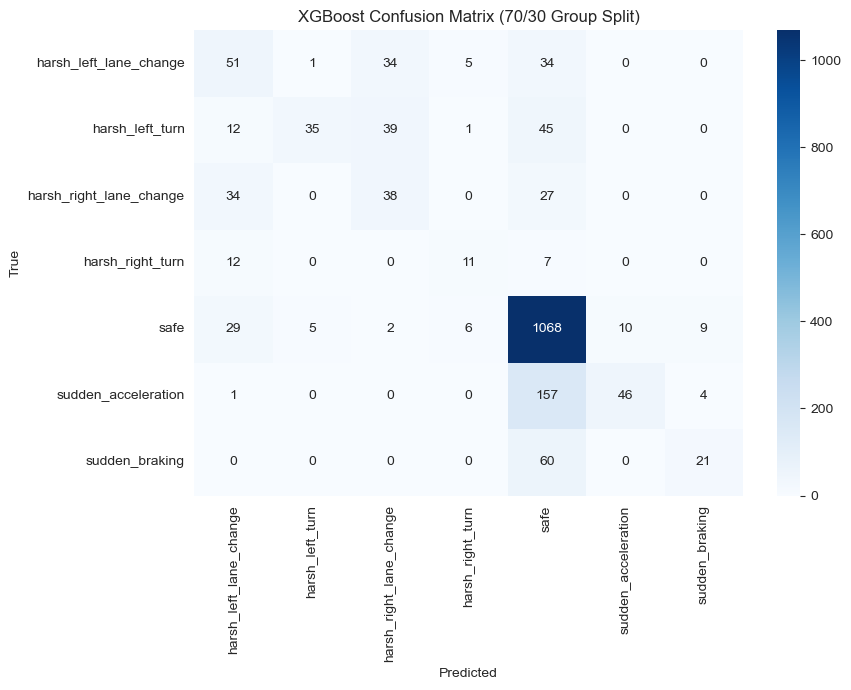

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title('XGBoost Confusion Matrix (70/30 Group Split)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Notes
- If results are still skewed toward safe, increase `min_event_ratio` in windowing to reduce label noise.
- You can also add FFT-based features to improve sudden-event separability.